In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from decorator import append
from sympy import rotations


In [2]:
""" Reading Datasets """
df=pd.read_csv(r"C:\Users\shiva\OneDrive\Documents\GitHub\Python_for_data_scientist\EDA\My Uber Drives - 2016.csv")

In [3]:
df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [4]:
df.columns

Index(['START_DATE*', 'END_DATE*', 'CATEGORY*', 'START*', 'STOP*', 'MILES*',
       'PURPOSE*'],
      dtype='object')

In [5]:
df.isnull().sum()

START_DATE*      0
END_DATE*        1
CATEGORY*        1
START*           1
STOP*            1
MILES*           0
PURPOSE*       503
dtype: int64

In [6]:
df[df.duplicated()]

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
492,6/28/2016 23:34,6/28/2016 23:59,Business,Durham,Cary,9.9,Meeting


In [8]:
df.drop(df.index[[751,761,798,807]],inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1152 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   START_DATE*  1152 non-null   object 
 1   END_DATE*    1151 non-null   object 
 2   CATEGORY*    1151 non-null   object 
 3   START*       1151 non-null   object 
 4   STOP*        1151 non-null   object 
 5   MILES*       1152 non-null   float64
 6   PURPOSE*     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 72.0+ KB


In [14]:
""" Renaming Columns"""
df.columns=["START_DATE","END_DATE","CATEGORY","START","STOP","MILE","PURPOSE"]
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILE,PURPOSE
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [15]:
""" Coverting START_DATE , END_DATE  INTO PROPER FORMAT"""
df["START_DATE"]=pd.to_datetime(df["START_DATE"],errors="coerce")
df["END_DATE"]=pd.to_datetime(df["END_DATE"],errors="coerce")

In [17]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILE,PURPOSE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


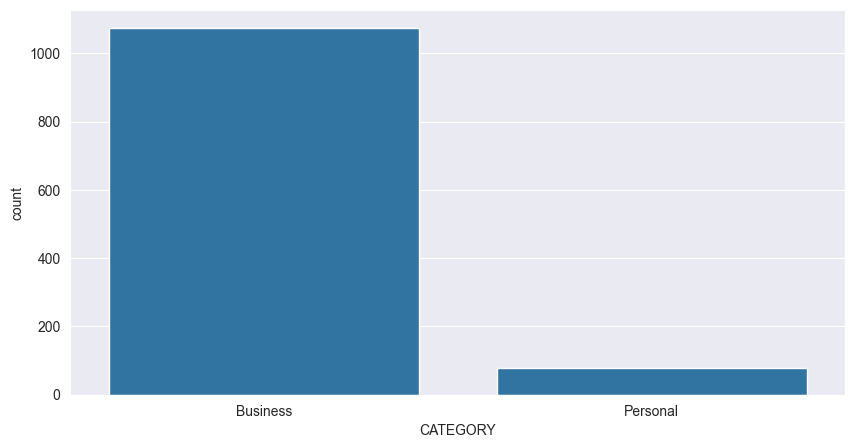

In [105]:
""" Count plot"""
plt.figure(figsize=(10,5))
sns.countplot(x=df["CATEGORY"]);

In [20]:
start_labels=df.START.value_counts().nlargest(10)
start_labels

START
Cary                201
Unknown Location    146
Morrisville          85
Whitebridge          68
Islamabad            56
Durham               37
Lahore               36
Raleigh              28
Kar?chi              27
Westpark Place       17
Name: count, dtype: int64

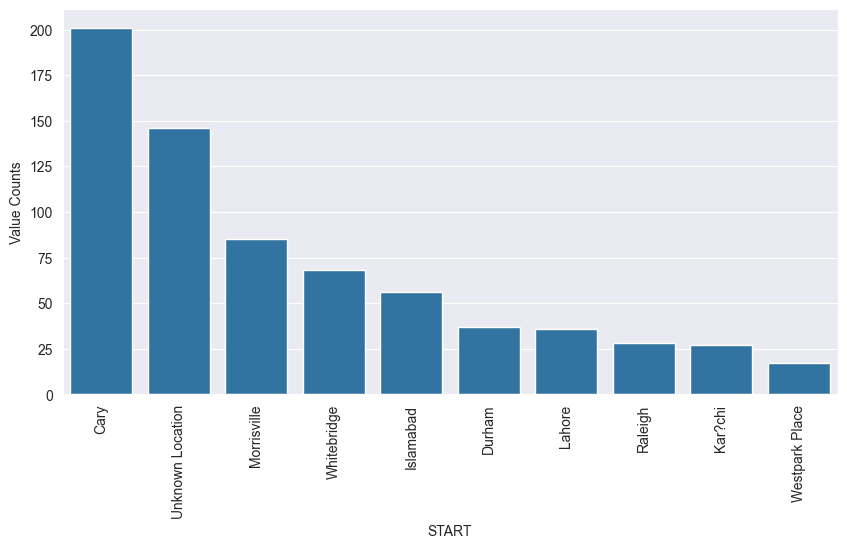

In [25]:
plt.figure(figsize=(10,5))
plt.xticks(rotation=90)
sns.barplot(start_labels)
plt.ylabel("Value Counts");

Text(0, 0.5, 'Value Count')

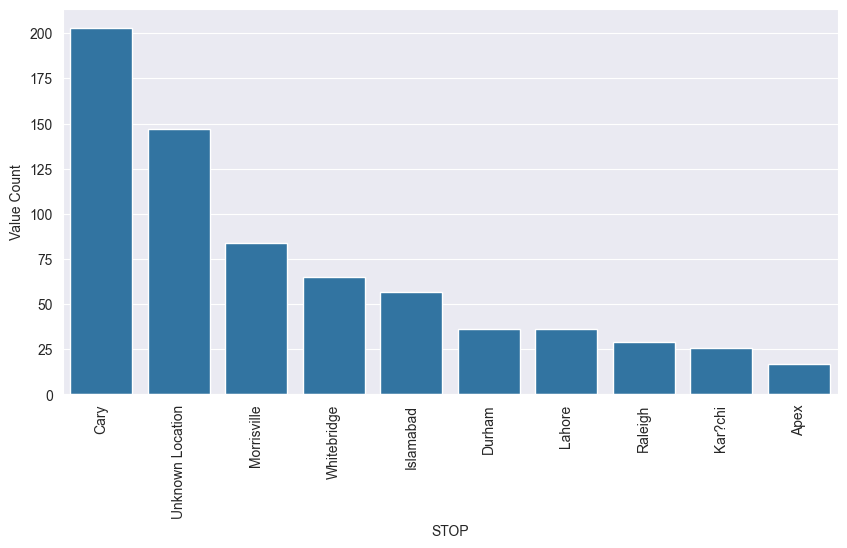

In [35]:
"""Bar Plot """
stop_labels=df.STOP.value_counts().nlargest(10)
plt.figure(figsize=(10,5))
plt.xticks(rotation=90)
sns.barplot(stop_labels)
plt.ylabel("Value Count")

In [42]:
""" Extracting months from columns Start_Date  """
df["MONTH"]=pd.DatetimeIndex(df["START_DATE"]).month
month_label={  1.0: "JAN",  2.0: "FEB",  3.0: "MAR",  4.0: "APR",  5.0: "MAY",  6.0: "JUN",  7.0: "JUL",  8.0: "AUG",  9.0: "SEP", 10.0: "OCT", 11.0:"NOV", 12.0:"DEC"}
df["MONTH"]=df.MONTH.map(month_label)

In [43]:
df.MONTH.unique()

array(['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP',
       'OCT', 'NOV', 'DEC', nan], dtype=object)

In [45]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILE,PURPOSE,MONTH
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,JAN
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN,JAN
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,JAN
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,JAN
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,JAN


Text(0, 0.5, 'Count of Month')

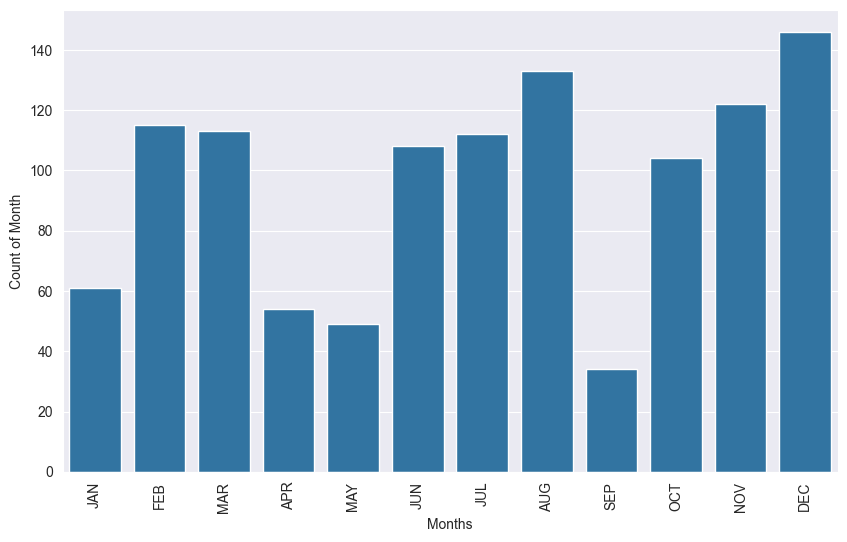

In [104]:
"""Month count Chart"""
plt.figure(figsize=(10,6))
plt.xticks(rotation=90)
sns.countplot(x=df["MONTH"])
plt.xlabel("Months")
plt.ylabel("Count of Month")

In [55]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILE,PURPOSE,MONTH
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,JAN
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN,JAN
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,JAN
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,JAN
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,JAN


In [58]:
""" Creating a dictionary that contains info about miles columns"""
miles_dic={}

for i in df.MILE:
    if i < 10:
        if "0-10 miles" not in miles_dic:
            miles_dic["0-10 miles"]=[i]
        else:
            miles_dic["0-10 miles"].append(i)
    elif i>=10 and i < 20 :
        if "10-20 miles" not in miles_dic:
            miles_dic["10-20 miles"]=[i]
        else:
            miles_dic["10-20 miles"].append(i)
    elif i>=20 and i<30:
        if "20-30 miles" not in miles_dic:
            miles_dic["20-30 miles"]=[i]
        else:
            miles_dic["20-30 miles"].append(i)
    elif i>=30 and i<40:
        if "30-40 miles" not in miles_dic:
            miles_dic["30-40 miles"] = [i]
        else:
            miles_dic["30-40 miles"].append(i)
    elif i>40 and i<50 :
        if "40-50 miles" not in miles_dic:
            miles_dic["40-50 miles"] =[i]
        else:
            miles_dic["40-50 miles"].append(i)
    else:
        if "Above 50 miles" not in miles_dic:
            miles_dic["Above 50 miles"]=[i]
        else:
            miles_dic["Above 50 miles"].append(i)


In [60]:
len_miles=[]
for key in miles_dic:
    len_miles.append((key,len(miles_dic[key])))


Text(0, 0.5, 'Count')

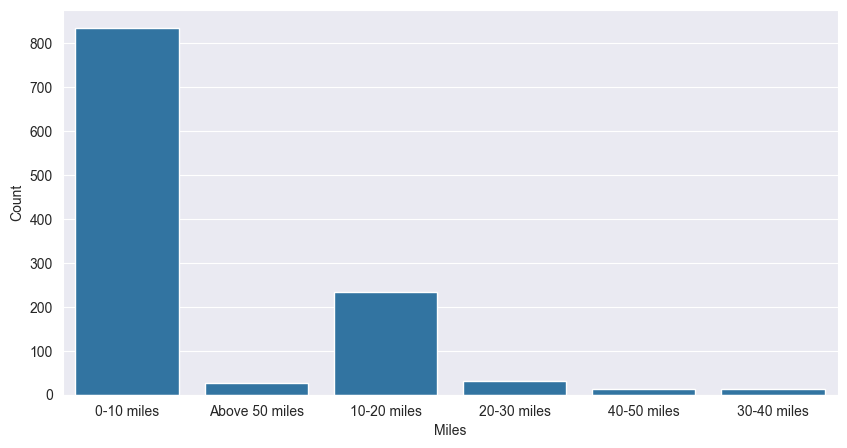

In [64]:
a,b=[],[]
for i , j in len_miles:
    a.append(i)
    b.append(j)

plt.figure(figsize=(10,5))
sns.barplot(x=a,y=b)
plt.xlabel("Miles")
plt.ylabel("Count")

In [66]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILE,PURPOSE,MONTH
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,JAN
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN,JAN
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,JAN
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,JAN
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,JAN


In [91]:
""" Now we want to know how many trips were made on Day Time and how many on Night Time """
df = df.dropna(subset=['START_DATE'])
t=pd.to_datetime("18:00:00").time()

In [93]:
df['DAY/NIGHT'] = df.apply(lambda x : 'NIGHT RIDE' if x['START_DATE'].time() > t else 'DAY RIDE', axis=1)

C:\Users\shiva\AppData\Local\Temp\ipykernel_2568\1057377304.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DAY/NIGHT'] = df.apply(lambda x : 'NIGHT RIDE' if x['START_DATE'].time() > t else 'DAY RIDE', axis=1)


Text(0.5, 0, 'Day/Night Ride')

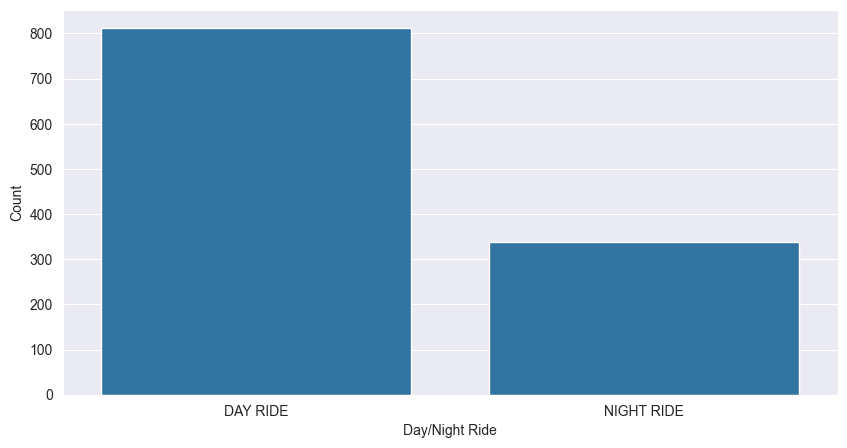

In [94]:
day_night_label=df["DAY/NIGHT"].value_counts()

""" Bar Plot"""

plt.figure(figsize=(10,5))
sns.barplot(day_night_label)
plt.ylabel("Count")
plt.xlabel("Day/Night Ride")

In [95]:
df["Day"]=df.START_DATE.dt.weekday


C:\Users\shiva\AppData\Local\Temp\ipykernel_2568\2948696364.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Day"]=df.START_DATE.dt.weekday


In [98]:
day_label = {
    0: 'Mon', 1: 'Tues', 2: 'Wed', 3: 'Thus', 4: 'Fir', 5: 'Sat', 6: 'Sun'
}
df['Day'] = df['Day'].map(day_label)



C:\Users\shiva\AppData\Local\Temp\ipykernel_2568\1839402494.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Day'] = df['Day'].map(day_label)


Text(0, 0.5, 'COUNT')

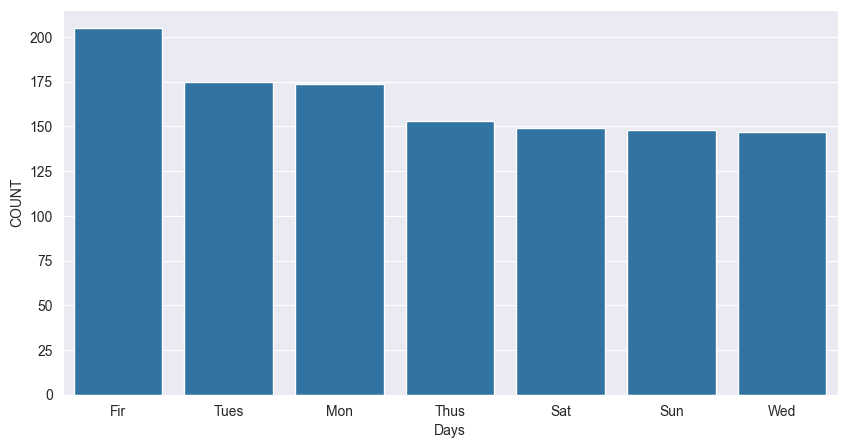

In [103]:
day_label=df.Day.value_counts()
""" bar plots of days """
plt.figure(figsize=(10,5))
sns.barplot(day_label)
plt.xlabel("Days")
plt.ylabel("COUNT")

<Axes: xlabel='Day', ylabel='count'>

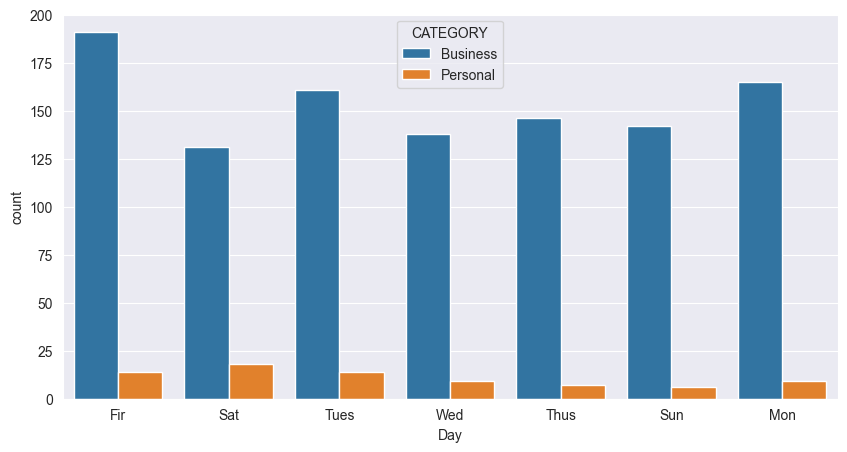

In [106]:
""" Count plot of day """
plt.figure(figsize=(10,5))
sns.countplot(hue="CATEGORY",x="Day",data=df)